In [15]:
import pandas as pd

data = {
    "year": [
        2017,2017,2017,2017,2017,2017,2017,2017,2017,2017,
        2016,2016,2016,2016,2016,2016,2016,2016,2016,2016,
        2015,2015,2015,2015,2015,2015,2015,2015,2015,2015
    ],
    
    "month": [
        12,11,10,9,8,7,6,5,4,3,
        12,11,10,9,8,7,6,5,4,3,
        12,11,10,9,8,7,6,5,4,3
    ],
    
    "interest_rate": [
        2.75,2.5,2.5,2.5,2.5,2.5,2.5,2.25,2.25,2.25,
        2.0,2.0,1.75,1.75,1.75,1.75,1.75,1.75,1.75,1.75,
        1.5,1.5,1.5,1.5,1.5,1.5,1.5,1.5,1.5,1.5
    ],
    
    "unemployment_rate": [
        5.3,5.3,5.3,5.3,5.4,5.6,5.5,5.5,5.5,5.6,
        5.7,5.9,6.0,5.9,5.8,6.1,6.2,6.1,6.1,5.9,
        6.0,6.1,6.2,6.3,6.4,6.5,6.3,6.2,6.1,6.0
    ],
    
    "index_price": [
        1464,1394,1357,1293,1256,1254,1234,1195,1159,1167,
        1130,1075,1047,965,943,958,971,949,884,866,
        850,840,830,820,810,805,800,790,780,770
    ]
}

df = pd.DataFrame(data)

df.head()

,year,month,interest_rate,unemployment_rate,index_price
0,2017,12,2.75,5.3,1464
1,2017,11,2.50,5.3,1394
2,2017,10,2.50,5.3,1357
3,2017,9,2.50,5.3,1293
4,2017,8,2.50,5.4,1256


In [16]:
#drop the unnecessary columns
df.drop(columns=['year','month'],axis=1,inplace=True)

In [17]:
df.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [18]:
df.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

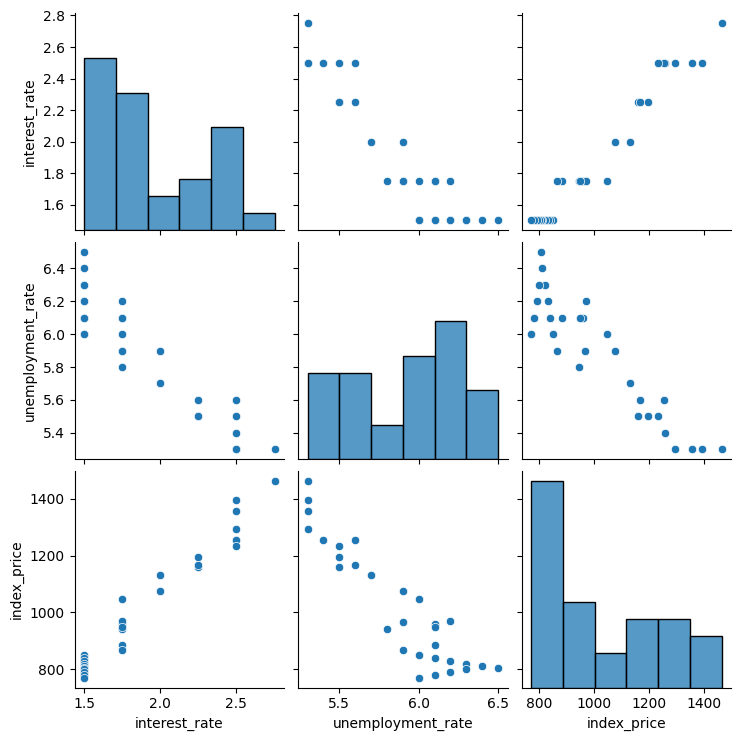

In [19]:
import seaborn as sns
sns.pairplot(df)

In [20]:
df.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.930631,0.977599
unemployment_rate,-0.930631,1.000000,-0.921232
index_price,0.977599,-0.921232,1.000000


In [21]:
# Independent and dependent Features

X = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [22]:
# train test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size =  0.25,random_state=42)

<Axes: xlabel='interest_rate', ylabel='index_price'>

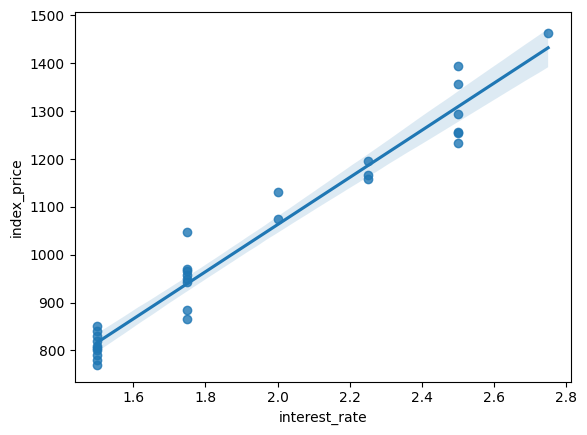

In [23]:
import seaborn as sns
sns.regplot(x=df['interest_rate'],y=df['index_price'])

<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

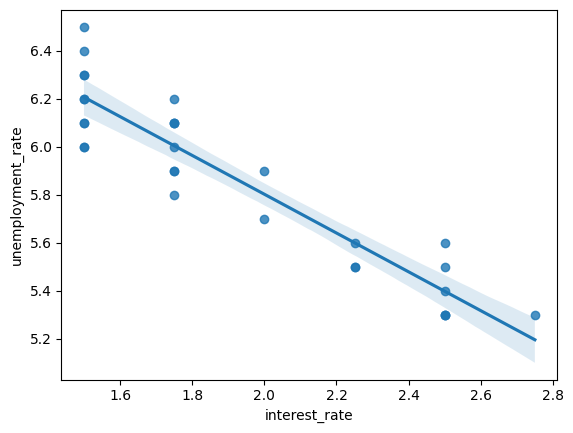

In [24]:
sns.regplot(x=df['interest_rate'],y=df['unemployment_rate'])

In [25]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

In [26]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train,y_train)
y_pred = lr.predict(X_test)

In [31]:
from sklearn.model_selection import cross_val_score
Validation_score = cross_val_score(lr,X_train,y_train,scoring="neg_mean_squared_error",
                cv=3)

In [35]:
import numpy as np
from sklearn.metrics import mean_squared_error,mean_absolute_error
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mse)
print("MSE",mse)
print("MAE",mae)
print("RMSE",rmse)

MSE 20363.208505961993
MAE 126.465909090909
RMSE 142.69971445648375


In [33]:
import numpy as np 
np.mean(Validation_score)

np.float64(-3909.5045149684593)